In [1]:
#imports
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import time
import os


In [3]:
device = torch.device(
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else 'cpu'
)

print(device)

cuda


In [4]:

#create transform for images and normalize
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5),
                 (0.5, 0.5, 0.5))
])

# Set batch size to 16 for the available GPU
# Good balance between memory usage and training speed
batch_size = 16

# Download dataset and apply transform
dataset = torchvision.datasets.EuroSAT(
    root='./data',
    download=True,
    transform=transform
)

# 80% train, 20% test
train_size = int(0.7 * len(dataset))
test_size = int(0.15 * len(dataset))
val_size = int(0.15 * len(dataset))

# Split data
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

def make_loaders(batch_size):
    # Final data prep
    trainloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4
    )

    valloader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4
    )

    testloader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4
    )

    return trainloader,valloader,testloader

# Set classes
classes = (
    'AnnualCrop',
    'Forest',
    'HerbaceousVegetation',
    'Highway',
    'Industrial',
    'Pasture',
    'PermanentCrop',
    'Residential',
    'River',
    'SeaLake'
    )

In [5]:
# Define CNN
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3,padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3,padding=1)
        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net().to(device)

In [6]:
# Loss definitiom
criterion = nn.CrossEntropyLoss()

In [7]:
# Keep In code to show preliminary idea, but function below much more efficient
"""
train_accuracies = []
val_accuracies = []

#Train Network
for epoch in range(2):  # loop over the dataset multiple times
    net.train()

    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

    # evaluate after this epoch
    eval(trainloader, train_accuracies)
    eval(valloader, val_accuracies)

print('Finished Training')
"""

"\ntrain_accuracies = []\nval_accuracies = []\n\n#Train Network\nfor epoch in range(2):  # loop over the dataset multiple times\n    net.train()\n\n    running_loss = 0.0\n\n    for i, data in enumerate(trainloader, 0):\n        # get the inputs; data is a list of [inputs, labels]\n        inputs, labels = data\n\n        # zero the parameter gradients\n        optimizer.zero_grad()\n\n        # forward + backward + optimize\n        outputs = net(inputs)\n        loss = criterion(outputs, labels)\n        loss.backward()\n        optimizer.step()\n\n        # print statistics\n        running_loss += loss.item()\n        if i % 2000 == 1999:    # print every 2000 mini-batches\n            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')\n            running_loss = 0.0\n\n    # evaluate after this epoch\n    eval(trainloader, train_accuracies)\n    eval(valloader, val_accuracies)\n\nprint('Finished Training')\n"

In [8]:
# Train Model Function
def train_model(model, trainloader, criterion, optimizer, tracker, epochs=10,seed=42):

    # Set random seed
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Make CUDA operations more reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        all_labels = []
        all_preds = []

        correct_pred = {classname: 0 for classname in classes}
        total_pred = {classname: 0 for classname in classes}

        total_correct = 0
        total = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predictions = torch.max(outputs, 1)

            total_correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())

            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1

        overall_accuracy = 100 * total_correct / total

        class_precision, class_recall, class_f1, support = precision_recall_fscore_support(
            all_labels,
            all_preds,
            average=None,
            labels=range(10),
            zero_division=0
        )

        class_precision = class_precision * 100
        class_recall = class_recall * 100
        class_f1 = class_f1 * 100

        overall_precision = class_precision.mean()
        overall_recall = class_recall.mean()
        overall_f1 = class_f1.mean()

        class_accuracy = []

        for classname in classes:
            accuracy = 100 * correct_pred[classname] / total_pred[classname]
            class_accuracy.append(accuracy)

        average_loss = running_loss / len(trainloader)

        tracker.append([
            average_loss,
            overall_accuracy,
            overall_precision,
            overall_recall,
            overall_f1,
            class_accuracy,
            class_precision.tolist(),
            class_recall.tolist(),
            class_f1.tolist(),
            support.tolist()
        ])

        print(
            "Done Epoch: ",
            f"Loss: {average_loss:.4f}"
        )

    if device.type == "cuda":
        torch.cuda.synchronize()

    training_time = time.time() - start_time

    # Store total training time
    tracker.append(training_time)

    return model

In [9]:
#Evaluate models

def eval(model, loader, tracker):
    model.eval()

    # Count correct and total predictions for each class
    correct_pred = {classname: 0 for classname in classes}
    total_pred = {classname: 0 for classname in classes}

    # Count correct and total predictions overall
    total_correct = 0
    total = 0

    # Store all labels and predictions
    all_labels = []
    all_preds = []

    # Synchronize GPU before starting timer
    if device.type == "cuda":
        torch.cuda.synchronize()

    # Start inference timer
    start_time = time.time()

    # Turn off gradient calculations
    with torch.no_grad():
        for data in loader:
            images, labels = data

            # Move data to same device as model
            images = images.to(device)
            labels = labels.to(device)

            # Get model outputs and predicted classes
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            # Count overall correct predictions
            total_correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Store labels and predictions
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())

            # Count correct predictions for each class
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1

    # Synchronize GPU before stopping timer
    if device.type == "cuda":
        torch.cuda.synchronize()

    # Calculate inference time
    inference_time = time.time() - start_time

    # Calculate overall accuracy
    overall_accuracy = 100 * total_correct / total

    # Calculate precision, recall, F1, and support for each class
    class_precision, class_recall, class_f1, support = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None,
        labels=range(10),
        zero_division=0
    )

    # Convert class metrics to percentages
    class_precision = class_precision * 100
    class_recall = class_recall * 100
    class_f1 = class_f1 * 100

    # Calculate overall macro precision, recall, and F1
    overall_precision = class_precision.mean()
    overall_recall = class_recall.mean()
    overall_f1 = class_f1.mean()

    # Store accuracy for each class
    class_accuracy = []

    # Calculate accuracy for each class
    for classname in classes:
        accuracy = 100 * correct_pred[classname] / total_pred[classname]
        class_accuracy.append(accuracy)

    # Store all evaluation metrics in tracker
    tracker.append([
        overall_accuracy,
        overall_precision,
        overall_recall,
        overall_f1,
        class_accuracy,
        class_precision.tolist(),
        class_recall.tolist(),
        class_f1.tolist(),
        support.tolist()
    ])

    # Store total inference time
    tracker.append(inference_time)

    # Return overall accuracy
    return overall_accuracy

In [10]:
def print_all_data(model_dict, name):

    train_tracker = model_dict["train_tracker"]
    val_tracker = model_dict["val_tracker"]

    print(f"\n{name}")
    print("=" * 60)

    print("\nTRAINING DATA")
    print("-" * 60)

    print(f"Epochs:            {model_dict['total_epochs']}")
    print(f"Learning Rate:     {model_dict['learning_rate']}")
    print(f"Batch Size:        {model_dict['batch_size']}")

    training_time = train_tracker[-1]

    for i, results in enumerate(train_tracker[:-1]):

        average_loss = results[0]
        overall_accuracy = results[1]
        overall_precision = results[2]
        overall_recall = results[3]
        overall_f1 = results[4]

        print(f"\nEpoch {i + 1}")
        print(f"Loss:              {average_loss:.4f}")
        print(f"Accuracy:          {overall_accuracy:.2f}%")
        print(f"Precision:         {overall_precision:.2f}%")
        print(f"Recall:            {overall_recall:.2f}%")
        print(f"F1:                {overall_f1:.2f}%")

    print(f"\nTotal Training Time: {training_time:.4f} seconds")

    print("\nVALIDATION DATA")
    print("-" * 60)

    results = val_tracker[-2]
    inference_time = val_tracker[-1]

    overall_accuracy = results[0]
    overall_precision = results[1]
    overall_recall = results[2]
    overall_f1 = results[3]

    class_accuracy = results[4]
    class_precision = results[5]
    class_recall = results[6]
    class_f1 = results[7]
    support = results[8]

    print(f"Overall Accuracy:  {overall_accuracy:.2f}%")
    print(f"Overall Precision: {overall_precision:.2f}%")
    print(f"Overall Recall:    {overall_recall:.2f}%")
    print(f"Overall F1:        {overall_f1:.2f}%")
    print(f"Inference Time:    {inference_time:.4f} seconds")

    print("\nPer-Class Metrics:")

    for j, classname in enumerate(classes):
        print(
            f"{classname:22s} "
            f"Accuracy: {class_accuracy[j]:6.2f}%  "
            f"Precision: {class_precision[j]:6.2f}%  "
            f"Recall: {class_recall[j]:6.2f}%  "
            f"F1: {class_f1[j]:6.2f}%  "
            f"Support: {support[j]}"
        )

In [11]:
#Plot training

def plot_tracker(train_tracker, model_name):

    # Get epoch data without final training time value
    epoch_data = train_tracker[:-1]

    # Create epoch numbers
    epochs = range(1, len(epoch_data) + 1)

    # Get overall metrics from each epoch
    losses = [results[0] for results in epoch_data]
    accuracies = [results[1] for results in epoch_data]
    precisions = [results[2] for results in epoch_data]
    recalls = [results[3] for results in epoch_data]
    f1_scores = [results[4] for results in epoch_data]

    # Plot training loss
    plt.figure()
    plt.plot(epochs, losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(model_name + " Training Loss")
    plt.show()

    # Plot overall training metrics
    plt.figure()
    plt.plot(epochs, accuracies, label="Accuracy")
    plt.plot(epochs, precisions, label="Precision")
    plt.plot(epochs, recalls, label="Recall")
    plt.plot(epochs, f1_scores, label="F1")
    plt.xlabel("Epoch")
    plt.ylabel("Percent")
    plt.title(model_name + " Training Metrics")
    plt.legend()
    plt.show()

In [12]:
#Now Transfer Learning:

#1. Fine Tuning whole ResNet:
#Load ResNet18 pretrained on ImageNet
model = models.resnet18(weights='IMAGENET1K_V1')

#Get number of inputs going into the final layer
num_ftrs = model.fc.in_features

#Replace the original 1000-class ImageNet output layer
#with a new layer for 10 EuroSAT classes
model.fc = nn.Linear(num_ftrs, 10)

#Move model to GPU if available
model = model.to(device)

In [13]:
#2. Only train output layer

#Load ResNet18 pretrained on ImageNet
model2 = models.resnet18(weights='IMAGENET1K_V1')

#Freeze all existing pretrained layers
for param in model2.parameters():
    param.requires_grad = False

#Get number of inputs going into the final layer
num_ftrs = model2.fc.in_features

#Replace the original classifier with a new 10-class layer
#(New layers have requires_grad=True by default)
model2.fc = nn.Linear(num_ftrs, 10)

#Move model to GPU if available
model2 = model2.to(device)


In [14]:
import copy

def train_many_models(batch_sizes, epoch_values, learning_rates):

    # Save original model weights
    initial_net = copy.deepcopy(net.state_dict())
    initial_model = copy.deepcopy(model.state_dict())
    initial_model2 = copy.deepcopy(model2.state_dict())

    best_self_made = {
        "accuracy": 0,
        "model": None,
        "batch_size": None,
        "learning_rate": None,
        "total_epochs": None,
        "train_tracker": None,
        "val_tracker": None
    }

    best_whole_net = copy.deepcopy(best_self_made)
    best_last_layer = copy.deepcopy(best_self_made)

    all_results = []

    for batch_size in batch_sizes:

        trainloader, valloader, testloader = make_loaders(batch_size)

        for learn_rate in learning_rates:

            # Reset models for this hyperparameter combination
            net.load_state_dict(initial_net)
            model.load_state_dict(initial_model)
            model2.load_state_dict(initial_model2)

            # Create optimizers for this learning rate
            optimizer_new = optim.SGD(
                net.parameters(),
                lr=learn_rate,
                momentum=0.9
            )

            optimizer1 = optim.SGD(
                model.parameters(),
                lr=learn_rate,
                momentum=0.9
            )

            optimizer2 = optim.SGD(
                model2.fc.parameters(),
                lr=learn_rate,
                momentum=0.9
            )

            # Create trackers for this hyperparameter combination
            train_tracker_self_made = []
            train_tracker_whole_net = []
            train_tracker_last_layer = []

            val_tracker_self_made = []
            val_tracker_whole_net = []
            val_tracker_last_layer = []

            self_training_time = 0
            whole_training_time = 0
            last_training_time = 0

            total_epochs = 0

            for num_epochs in epoch_values:

                # Train self-made CNN
                temp_tracker = []

                train_model(
                    net,
                    trainloader,
                    criterion,
                    optimizer_new,
                    temp_tracker,
                    epochs=num_epochs
                )

                self_training_time += temp_tracker[-1]
                train_tracker_self_made.extend(temp_tracker[:-1])

                # Train whole ResNet
                temp_tracker = []

                train_model(
                    model,
                    trainloader,
                    criterion,
                    optimizer1,
                    temp_tracker,
                    epochs=num_epochs
                )

                whole_training_time += temp_tracker[-1]
                train_tracker_whole_net.extend(temp_tracker[:-1])

                # Train last-layer ResNet
                temp_tracker = []

                train_model(
                    model2,
                    trainloader,
                    criterion,
                    optimizer2,
                    temp_tracker,
                    epochs=num_epochs
                )

                last_training_time += temp_tracker[-1]
                train_tracker_last_layer.extend(temp_tracker[:-1])

                total_epochs += num_epochs

                # Evaluate all three models
                self_accuracy = eval(
                    net,
                    valloader,
                    val_tracker_self_made
                )

                whole_accuracy = eval(
                    model,
                    valloader,
                    val_tracker_whole_net
                )

                last_accuracy = eval(
                    model2,
                    valloader,
                    val_tracker_last_layer
                )

                # Build complete training trackers for saving
                self_tracker_save = (
                    copy.deepcopy(train_tracker_self_made)
                    + [self_training_time]
                )

                whole_tracker_save = (
                    copy.deepcopy(train_tracker_whole_net)
                    + [whole_training_time]
                )

                last_tracker_save = (
                    copy.deepcopy(train_tracker_last_layer)
                    + [last_training_time]
                )

                # Save best self-made CNN
                if self_accuracy > best_self_made["accuracy"]:

                    best_self_made = {
                        "accuracy": self_accuracy,
                        "model": copy.deepcopy(net),
                        "batch_size": batch_size,
                        "learning_rate": learn_rate,
                        "total_epochs": total_epochs,
                        "train_tracker": self_tracker_save,
                        "val_tracker": copy.deepcopy(val_tracker_self_made)
                    }

                # Save best whole ResNet
                if whole_accuracy > best_whole_net["accuracy"]:

                    best_whole_net = {
                        "accuracy": whole_accuracy,
                        "model": copy.deepcopy(model),
                        "batch_size": batch_size,
                        "learning_rate": learn_rate,
                        "total_epochs": total_epochs,
                        "train_tracker": whole_tracker_save,
                        "val_tracker": copy.deepcopy(val_tracker_whole_net)
                    }

                # Save best last-layer ResNet
                if last_accuracy > best_last_layer["accuracy"]:

                    best_last_layer = {
                        "accuracy": last_accuracy,
                        "model": copy.deepcopy(model2),
                        "batch_size": batch_size,
                        "learning_rate": learn_rate,
                        "total_epochs": total_epochs,
                        "train_tracker": last_tracker_save,
                        "val_tracker": copy.deepcopy(val_tracker_last_layer)
                    }

                # Save results for this checkpoint
                all_results.append({
                    "batch_size": batch_size,
                    "learning_rate": learn_rate,
                    "total_epochs": total_epochs,
                    "self_made_accuracy": self_accuracy,
                    "whole_net_accuracy": whole_accuracy,
                    "last_layer_accuracy": last_accuracy,
                    "self_made_train_tracker": self_tracker_save,
                    "self_made_val_tracker": copy.deepcopy(val_tracker_self_made),
                    "whole_net_train_tracker": whole_tracker_save,
                    "whole_net_val_tracker": copy.deepcopy(val_tracker_whole_net),
                    "last_layer_train_tracker": last_tracker_save,
                    "last_layer_val_tracker": copy.deepcopy(val_tracker_last_layer)
                })

    return (
        best_self_made,
        best_whole_net,
        best_last_layer,
        all_results
    )

In [ ]:
#Train Models
batch_sizes = [8,16]
epoch_values = [3,3,3,3] #each next value is an increment, so this will test epoch_values[0],epoch_values[0]+epoch_values[1],etc
learning_rates = [0.001]


best_self_made,best_whole_net,best_last_layer,all_results = train_many_models(batch_sizes,epoch_values,learning_rates)


Done Epoch:  Loss: 1.6736
Done Epoch:  Loss: 1.0885
Done Epoch:  Loss: 0.8721
Done Epoch:  Loss: 0.6513
Done Epoch:  Loss: 0.3181
Done Epoch:  Loss: 0.2223
Done Epoch:  Loss: 1.0118
Done Epoch:  Loss: 0.9065
Done Epoch:  Loss: 0.8764
Done Epoch:  Loss: 0.7442
Done Epoch:  Loss: 0.6393
Done Epoch:  Loss: 0.5543
Done Epoch:  Loss: 0.1428
Done Epoch:  Loss: 0.0782
Done Epoch:  Loss: 0.0559
Done Epoch:  Loss: 0.8737
Done Epoch:  Loss: 0.8717
Done Epoch:  Loss: 0.8558
Done Epoch:  Loss: 0.4769
Done Epoch:  Loss: 0.4015
Done Epoch:  Loss: 0.3341
Done Epoch:  Loss: 0.0475
Done Epoch:  Loss: 0.0313
Done Epoch:  Loss: 0.0305
Done Epoch:  Loss: 0.8696
Done Epoch:  Loss: 0.8666
Done Epoch:  Loss: 0.8516
Done Epoch:  Loss: 0.2841
Done Epoch:  Loss: 0.2323
Done Epoch:  Loss: 0.1900



Self Made CNN

TRAINING DATA
------------------------------------------------------------
Epochs:            2
Learning Rate:     0.001
Batch Size:        4

Epoch 1
Loss:              1.5426
Accuracy:          39.91%
Precision:         38.44%
Recall:            38.75%
F1:                37.15%

Epoch 2
Loss:              0.9434
Accuracy:          64.79%
Precision:         63.42%
Recall:            64.00%
F1:                63.57%

Total Training Time: 121.0331 seconds

VALIDATION DATA
------------------------------------------------------------
Overall Accuracy:  68.74%
Overall Precision: 70.09%
Overall Recall:    68.71%
Overall F1:        67.88%
Inference Time:    11.2216 seconds

Per-Class Metrics:
AnnualCrop             Accuracy:  78.54%  Precision:  79.91%  Recall:  78.54%  F1:  79.22%  Support: 466
Forest                 Accuracy:  84.69%  Precision:  65.53%  Recall:  84.69%  F1:  73.89%  Support: 431
HerbaceousVegetation   Accuracy:  38.88%  Precision:  79.00%  Recall:  38.88% 

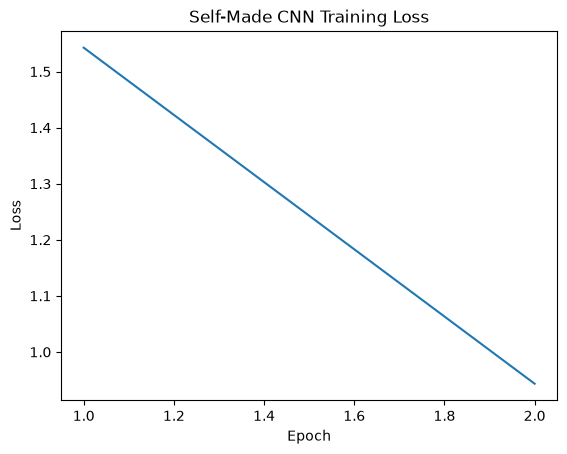

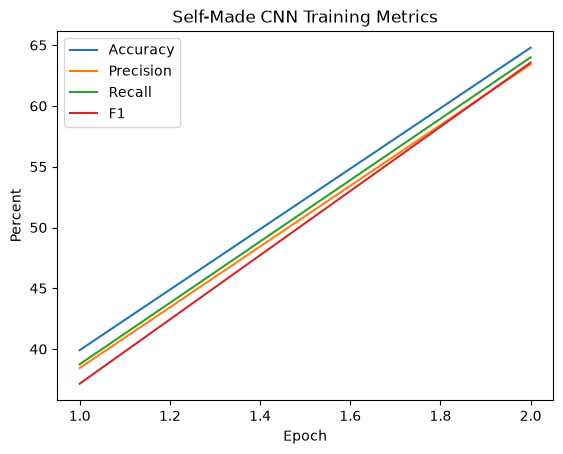

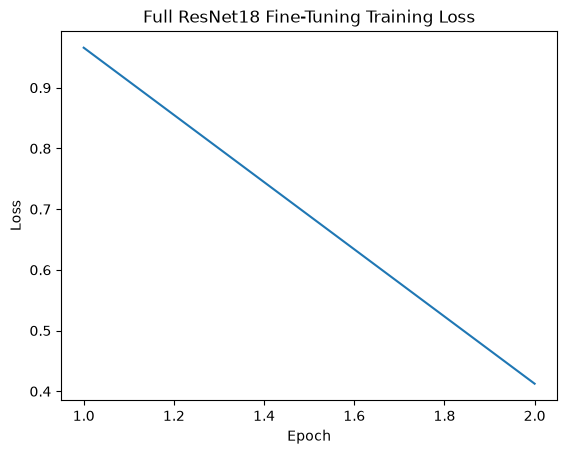

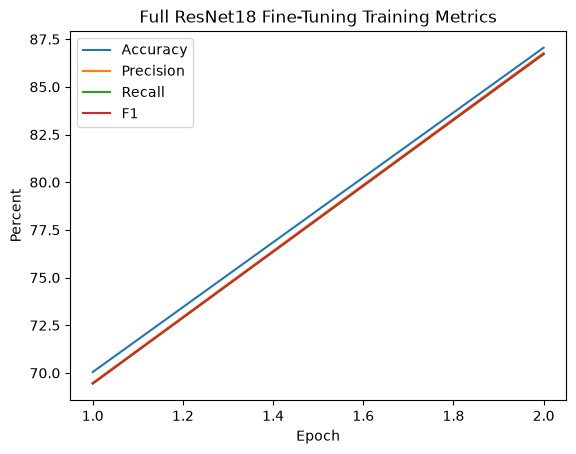

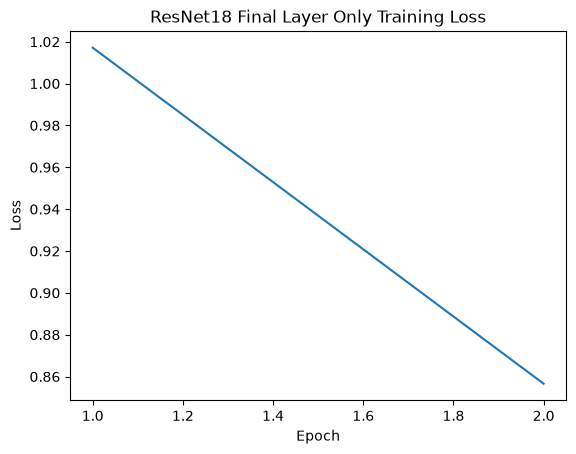

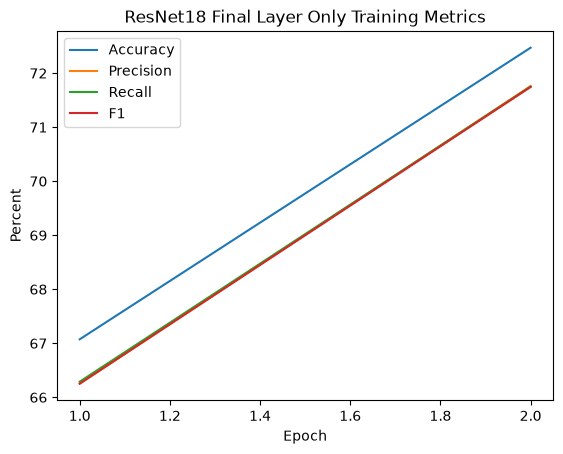

In [ ]:
#Print Training & Evaluation Results
print_all_data(best_self_made, "Self Made CNN")
print_all_data(best_whole_net, "Fine Tune Whole Net")
print_all_data(best_last_layer, "Last Layer Only")

#Graph Training & Results
plot_tracker(
    best_self_made["train_tracker"],
    "Self-Made CNN"
)

plot_tracker(
    best_whole_net["train_tracker"],
    "Full ResNet18 Fine-Tuning"
)

plot_tracker(
    best_last_layer["train_tracker"],
    "ResNet18 Final Layer Only"
)

In [ ]:
if (False):
    # Directory
    save_dir = r"C:\Users\samue\OneDrive\Desktop\ML Code\Proj2\EuroSAT\models"

    # Create the directory if it does not already exist
    os.makedirs(save_dir, exist_ok=True)

    # Save each model's trained weights
    torch.save(
        model_self_made.state_dict(),
        os.path.join(save_dir, "self_made_cnn.pth")
    )

    torch.save(
        model_whole_net.state_dict(),
        os.path.join(save_dir, "resnet18_finetuned.pth")
    )

    torch.save(
        model_last_layer.state_dict(),
        os.path.join(save_dir, "resnet18_last_layer.pth")
    )

    #Code to load each model for future reference
    r"""
    #1. Self Made
    # Recreate model architecture
    model_self_made = Net().to(device)

    # Load saved weights
    model_self_made.load_state_dict(
        torch.load(
            r"C:\Users\samue\OneDrive\Desktop\ML Code\Proj2\EuroSAT\models\self_made_cnn.pth",
            map_location=device
        )
    )

    # Put model in evaluation mode
    model_self_made.eval()

    # -----------------------------------------------------
    # 2. Fine Tuned
    # Recreate ResNet18 architecture
    model_whole_net = models.resnet18(weights=None)

    # Replace final layer with 10 outputs
    model_whole_net.fc = nn.Linear(model_whole_net.fc.in_features, 10)

    # Move model to device
    model_whole_net = model_whole_net.to(device)

    # Load saved weights
    model_whole_net.load_state_dict(
        torch.load(
            r"C:\Users\samue\OneDrive\Desktop\ML Code\Proj2\EuroSAT\models\resnet18_finetuned.pth",
            map_location=device
        )
    )

    # Put model in evaluation mode
    model_whole_net.eval()

    # -----------------------------------------------------
    # 3. Final Layer Only
    # Recreate ResNet18 architecture
    model_last_layer = models.resnet18(weights=None)

    # Replace final layer with 10 outputs
    model_last_layer.fc = nn.Linear(model_last_layer.fc.in_features, 10)

    # Move model to device
    model_last_layer = model_last_layer.to(device)

    # Load saved weights
    model_last_layer.load_state_dict(
        torch.load(
            r"C:\Users\samue\OneDrive\Desktop\ML Code\Proj2\EuroSAT\models\resnet18_last_layer.pth",
            map_location=device
        )
    )

    # Put model in evaluation mode
    model_last_layer.eval()
    """